In [1]:
import sys, os
os.chdir("..")
sys.path.insert(0, "./src")

from unfold.tools.Unfolder_rho import Unfolder
from unfold.utils.merge_helpers import *
import pickle as pkl
from unfold.tools.io import load_pkls

In [22]:
#filename_mc = './inputs/rho/jms_pythiaV2_all_syst.pkl', filename_data = "./inputs/rho/rho_dataV2_all.pkl"
out_data, out_mc = load_pkls( "./inputs/rho/rho_dataV2_all.pkl", './inputs/rho/jms_pythiaV2_all_syst.pkl', )
with open('./inputs/rho/herwig_all.pkl', 'rb') as f:
    out_herwig = pkl.load(f)

In [23]:
# import numpy as np
# ratio_store = []
# for i in range(1,4):
#     import matplotlib.pyplot as plt

#     h_data = out_data["ptjet_rhojet_g_reco"].project("ptreco","mpt_reco")[i, :]
#     h_mc   = out_mc["ptjet_rhojet_g_reco"].project("ptreco","mpt_reco")[i, :]

#     data_vals = np.asarray(h_data.values())
#     mc_vals = np.asarray(h_mc.values())

#     edges = h_data.axes[0].edges
#     centers = 0.5*(edges[:-1] + edges[1:])

    

#     # plot ratio on a second y-axis
#     main_ax = plt.gca()

#     # normalize by sum
#     dsum = data_vals.sum()
#     msum = mc_vals.sum()
#     if dsum != 0:
#         data_vals = data_vals / dsum
#     if msum != 0:
#         mc_vals = mc_vals / msum

#     plt.gca().step(centers, data_vals, where='mid', label="data", color="black")
#     plt.gca().step(centers, mc_vals, where='mid', label="mc", color="red")

#     # separate figure for the ratio
#     fig2, ax2 = plt.subplots()
#     ax2.set_xlabel(r"$\log(\rho^2)$, Groomed")
#     ax2.set_ylabel("data / mc")

#     # return focus to the main axes so subsequent plotting (e.g. response) uses it
#     plt.sca(main_ax)

#     # reuse a single ratio figure/axis for all iterations so all ratios are overlaid
#     if 'shared_ratio_ax' not in globals():
#         shared_ratio_fig = fig2
#         shared_ratio_ax = ax2
#     else:
#         plt.close(fig2)            # close the extra figure just created this iteration
#         fig2 = shared_ratio_fig
#         ax2 = shared_ratio_ax
#     ratio = np.divide(data_vals, mc_vals, out=np.zeros_like(data_vals, dtype=float), where=mc_vals!=0)
#     ratio_store.append(ratio)
#     #ax2.plot(centers, ratio, marker='o', color='green', label="data/mc", alpha=0.7)
#     #ax2.set_ylabel("data / mc")
#     #out_mc["response_matrix_rho_g"].project("ptreco","mpt_reco")[i, :].plot(label="Response projection", color="blue", ls = '--', alpha = 0.5, density = True)
#     plt.xlabel(r"$\log(\rho^2)$, Groomed")
#     import matplotlib.pyplot as plt
#     plt.legend()
#     plt.show()
# # plot all ratios together
# fig3, ax3 = plt.subplots()
# ax3.set_xlabel(r"$\log(\rho^2)$, Groomed")
# ax3.set_ylabel("data / mc")
# for i, ratio in enumerate(ratio_store):
#     ax3.plot(centers, ratio, marker='o', label=f"pt bin {i+1}", alpha=0.7)
# plt.ylim(0, 2)
# plt.legend()
# plt.show()

/tmp/ipykernel_3847/2694927030.py:57: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio_h, edges, yerr=ratio_h * np.sqrt((data_errs/data_vals)**2 + (herwig_errs/herwig_vals)**2), label="Data/HERWIG7", color="blue", ls='--', alpha=0.7, ax=ratio_ax)


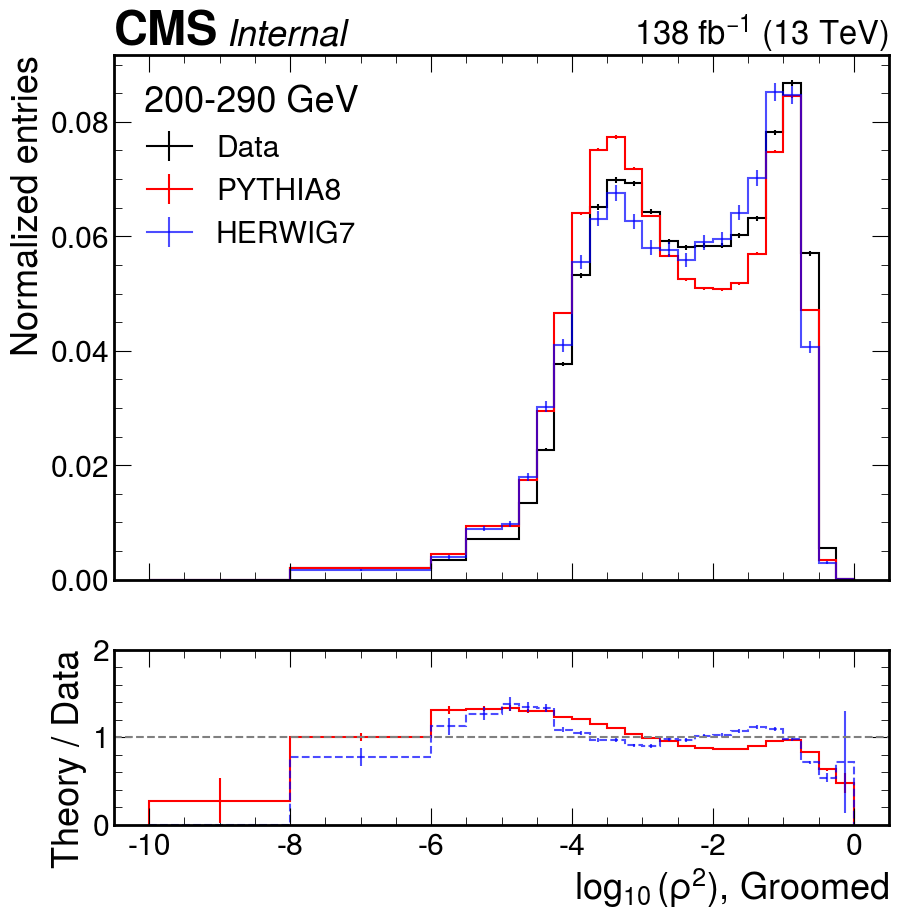

/tmp/ipykernel_3847/2694927030.py:56: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio, edges, yerr=ratio * np.sqrt((data_errs/data_vals)**2 + (mc_errs/mc_vals)**2), label="Data/Theory", color="r", ax=ratio_ax)
/tmp/ipykernel_3847/2694927030.py:57: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio_h, edges, yerr=ratio_h * np.sqrt((data_errs/data_vals)**2 + (herwig_errs/herwig_vals)**2), label="Data/HERWIG7", color="blue", ls='--', alpha=0.7, ax=ratio_ax)


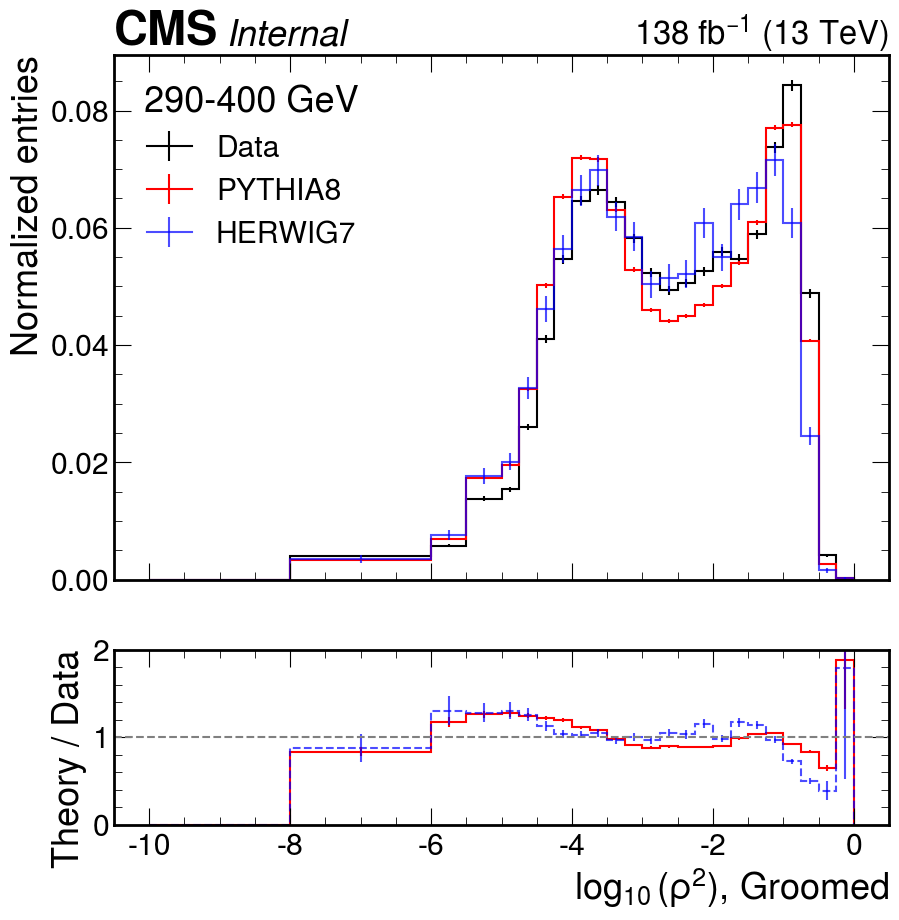

/tmp/ipykernel_3847/2694927030.py:56: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio, edges, yerr=ratio * np.sqrt((data_errs/data_vals)**2 + (mc_errs/mc_vals)**2), label="Data/Theory", color="r", ax=ratio_ax)
/tmp/ipykernel_3847/2694927030.py:57: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio_h, edges, yerr=ratio_h * np.sqrt((data_errs/data_vals)**2 + (herwig_errs/herwig_vals)**2), label="Data/HERWIG7", color="blue", ls='--', alpha=0.7, ax=ratio_ax)


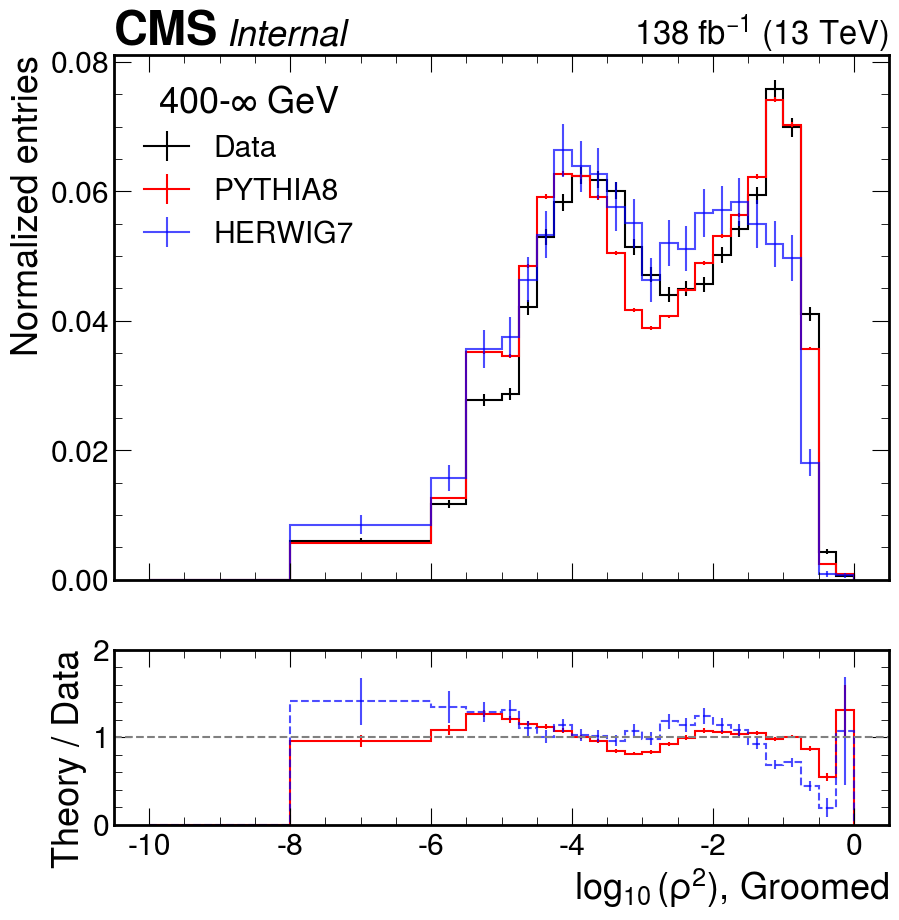

In [31]:
pt_bins = ["", r"200-290 GeV", r"290-400 GeV", r"400-$\infty$ GeV"]
import numpy as np
import mplhep as hep
ratio_store = []
hep.style.use("CMS")  # Use CMS style for better aesthetics
for i in range(1,4):
    import matplotlib.pyplot as plt

    h_data = out_data["ptjet_rhojet_g_reco"].project("ptreco","mpt_reco")[i, :]
    h_mc   = out_mc["ptjet_rhojet_g_reco"].project("ptreco","mpt_reco")[i, :]
    h_herwig = out_herwig["ptjet_rhojet_g_reco"].project("ptreco","mpt_reco")[i, :]

    data_vals = np.asarray(h_data.values())
    mc_vals = np.asarray(h_mc.values())
    herwig_vals = np.asarray(h_herwig.values())

    data_errs = np.asarray(h_data.variances())**0.5
    mc_errs = np.asarray(h_mc.variances())**0.5
    herwig_errs = np.asarray(h_herwig.variances())**0.5

    edges = h_data.axes[0].edges
    centers = 0.5*(edges[:-1] + edges[1:])

    # ratio plot axis setup 3:1
    fig, (main_ax, ratio_ax) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # normalize by sum
    dsum = data_vals.sum()
    msum = mc_vals.sum()
    hsum = herwig_vals.sum()
    if dsum != 0:
        data_vals = data_vals / dsum
        data_errs = data_errs / dsum
    if msum != 0:
        mc_vals = mc_vals / msum
        mc_errs = mc_errs / msum
    if hsum != 0:
        herwig_vals = herwig_vals / hsum
        herwig_errs = herwig_errs / hsum
    

    # plt.gca().step(centers, data_vals, where='mid', label="data", color="black")
    # plt.gca().step(centers, mc_vals, where='mid', label="mc", color="red")
    plt.sca(main_ax)
    hep.histplot( data_vals, edges, yerr=data_errs, label="Data", color="black", )
    hep.histplot( mc_vals, edges, yerr=mc_errs, label="PYTHIA8", color="red", )
    hep.histplot( herwig_vals, edges, yerr=herwig_errs, label="HERWIG7", color="blue", alpha = 0.7)
    plt.ylabel("Normalized entries")
    plt.legend(title = pt_bins[i])

    hep.cms.label("Internal", data = True, lumi = 138)
    ratio = np.divide( mc_vals, data_vals, out=np.zeros_like(data_vals, dtype=float), where=data_vals!=0)
    ratio_h = np.divide( herwig_vals, data_vals, out=np.zeros_like(data_vals, dtype=float), where=data_vals!=0)

    plt.sca(ratio_ax)
    hep.histplot( ratio, edges, yerr=ratio * np.sqrt((data_errs/data_vals)**2 + (mc_errs/mc_vals)**2), label="Data/Theory", color="r", ax=ratio_ax)
    hep.histplot( ratio_h, edges, yerr=ratio_h * np.sqrt((data_errs/data_vals)**2 + (herwig_errs/herwig_vals)**2), label="Data/HERWIG7", color="blue", ls='--', alpha=0.7, ax=ratio_ax)
    plt.axhline(1, color='gray', ls='--')
    #ax2.plot(centers, ratio, marker='o', color='green', label="data/mc", alpha=0.7)
    #ax2.set_ylabel("data / mc")
    #out_mc["response_matrix_rho_g"].project("ptreco","mpt_reco")[i, :].plot(label="Response projection", color="blue", ls = '--', alpha = 0.5, density = True)
    plt.xlabel(r"$\log_{10}(\rho^2)$, Groomed")
    plt.ylim(0, 2)
    plt.ylabel("Theory / Data")
    #plt.legend()
    plt.savefig(f"./outputs/rho/input_groomed_{i}.pdf")
    plt.show()


/tmp/ipykernel_3847/3461587482.py:56: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio, edges, yerr=ratio * np.sqrt((data_errs/data_vals)**2 + (mc_errs/mc_vals)**2), label="Data/Theory", color="r", ax=ratio_ax)
/tmp/ipykernel_3847/3461587482.py:57: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio_h, edges, yerr=ratio_h * np.sqrt((data_errs/data_vals)**2 + (herwig_errs/herwig_vals)**2), label="Data/HERWIG7", color="blue", ls='--', alpha=0.7, ax=ratio_ax)


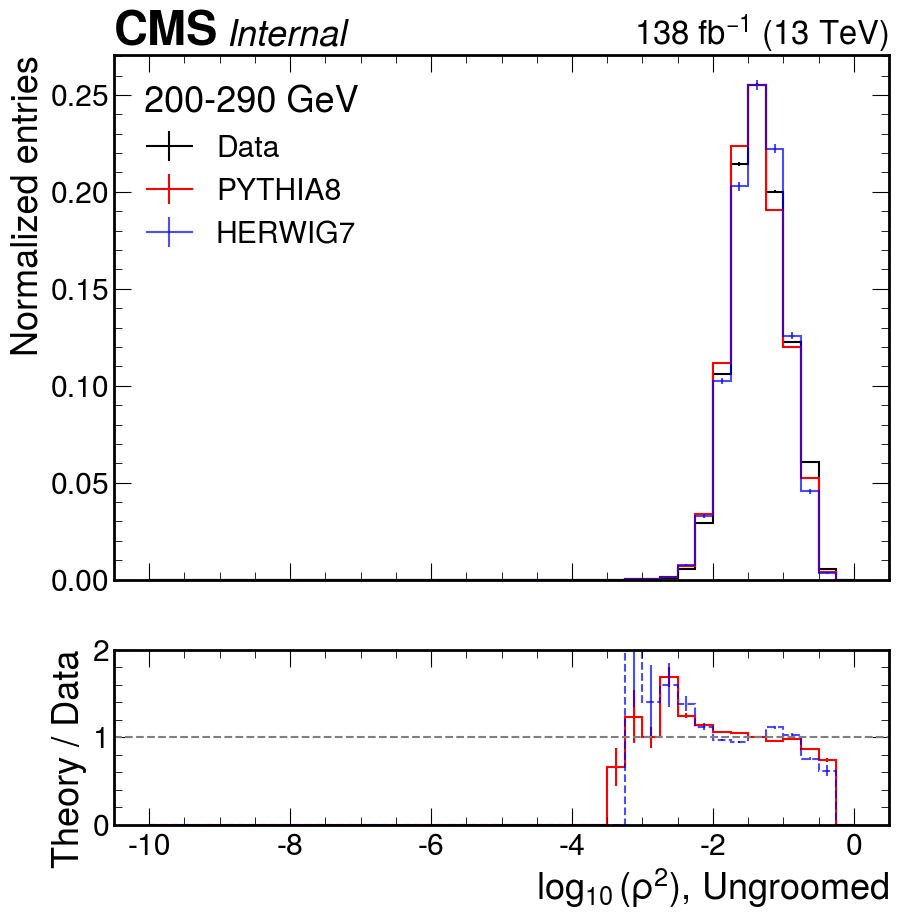

/tmp/ipykernel_3847/3461587482.py:56: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio, edges, yerr=ratio * np.sqrt((data_errs/data_vals)**2 + (mc_errs/mc_vals)**2), label="Data/Theory", color="r", ax=ratio_ax)
/tmp/ipykernel_3847/3461587482.py:57: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio_h, edges, yerr=ratio_h * np.sqrt((data_errs/data_vals)**2 + (herwig_errs/herwig_vals)**2), label="Data/HERWIG7", color="blue", ls='--', alpha=0.7, ax=ratio_ax)


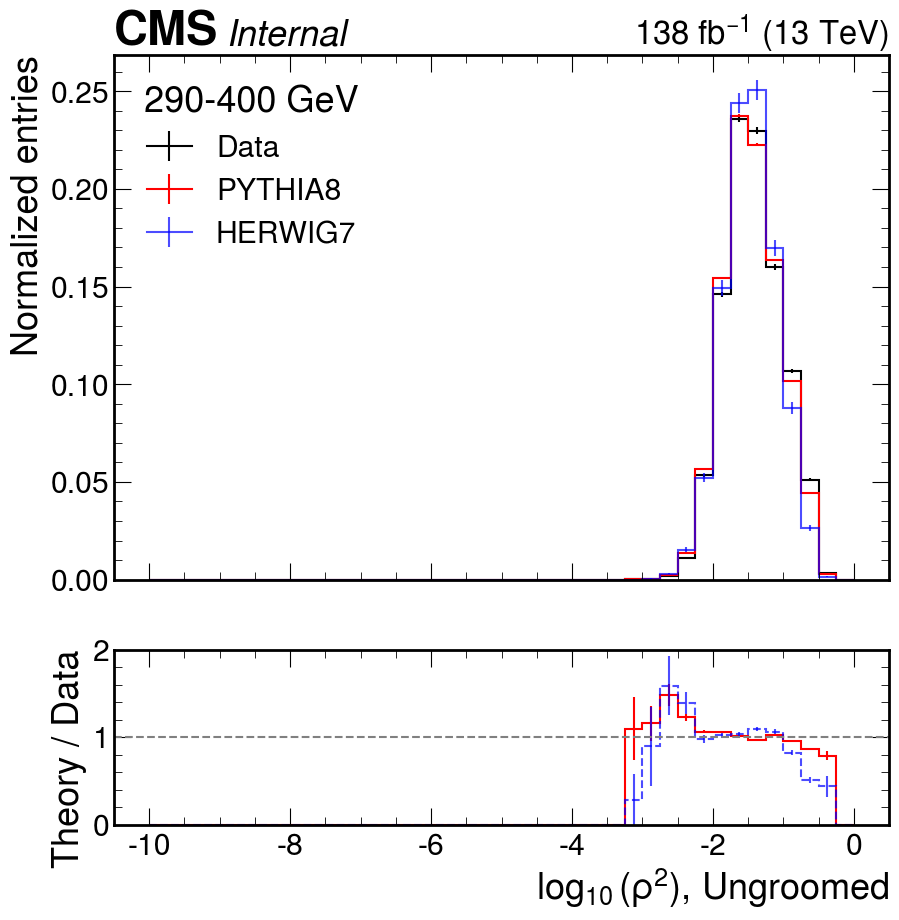

/tmp/ipykernel_3847/3461587482.py:56: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio, edges, yerr=ratio * np.sqrt((data_errs/data_vals)**2 + (mc_errs/mc_vals)**2), label="Data/Theory", color="r", ax=ratio_ax)
/tmp/ipykernel_3847/3461587482.py:57: RuntimeWarning: invalid value encountered in divide
  hep.histplot( ratio_h, edges, yerr=ratio_h * np.sqrt((data_errs/data_vals)**2 + (herwig_errs/herwig_vals)**2), label="Data/HERWIG7", color="blue", ls='--', alpha=0.7, ax=ratio_ax)


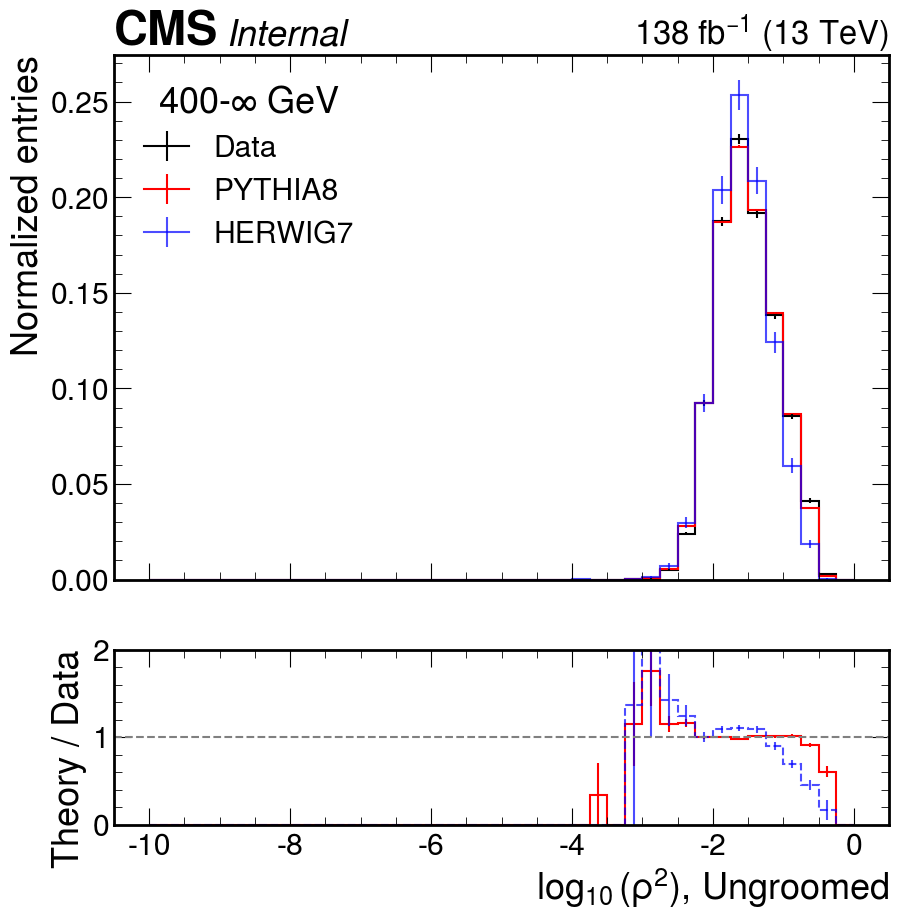

In [32]:
pt_bins = ["", r"200-290 GeV", r"290-400 GeV", r"400-$\infty$ GeV"]
import numpy as np
import mplhep as hep
ratio_store = []
hep.style.use("CMS")  # Use CMS style for better aesthetics
for i in range(1,4):
    import matplotlib.pyplot as plt

    h_data = out_data["ptjet_rhojet_u_reco"].project("ptreco","mpt_reco")[i, :]
    h_mc   = out_mc["ptjet_rhojet_u_reco"].project("ptreco","mpt_reco")[i, :]
    h_herwig = out_herwig["ptjet_rhojet_u_reco"].project("ptreco","mpt_reco")[i, :]

    data_vals = np.asarray(h_data.values())
    mc_vals = np.asarray(h_mc.values())
    herwig_vals = np.asarray(h_herwig.values())

    data_errs = np.asarray(h_data.variances())**0.5
    mc_errs = np.asarray(h_mc.variances())**0.5
    herwig_errs = np.asarray(h_herwig.variances())**0.5

    edges = h_data.axes[0].edges
    centers = 0.5*(edges[:-1] + edges[1:])

    # ratio plot axis setup 3:1
    fig, (main_ax, ratio_ax) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # normalize by sum
    dsum = data_vals.sum()
    msum = mc_vals.sum()
    hsum = herwig_vals.sum()
    if dsum != 0:
        data_vals = data_vals / dsum
        data_errs = data_errs / dsum
    if msum != 0:
        mc_vals = mc_vals / msum
        mc_errs = mc_errs / msum
    if hsum != 0:
        herwig_vals = herwig_vals / hsum
        herwig_errs = herwig_errs / hsum
    

    # plt.gca().step(centers, data_vals, where='mid', label="data", color="black")
    # plt.gca().step(centers, mc_vals, where='mid', label="mc", color="red")
    plt.sca(main_ax)
    hep.histplot( data_vals, edges, yerr=data_errs, label="Data", color="black", )
    hep.histplot( mc_vals, edges, yerr=mc_errs, label="PYTHIA8", color="red", )
    hep.histplot( herwig_vals, edges, yerr=herwig_errs, label="HERWIG7", color="blue", alpha = 0.7)
    plt.ylabel("Normalized entries")
    plt.legend(title = pt_bins[i])

    hep.cms.label("Internal", data = True, lumi = 138)
    ratio = np.divide( mc_vals, data_vals, out=np.zeros_like(data_vals, dtype=float), where=data_vals!=0)
    ratio_h = np.divide( herwig_vals, data_vals, out=np.zeros_like(data_vals, dtype=float), where=data_vals!=0)

    plt.sca(ratio_ax)
    hep.histplot( ratio, edges, yerr=ratio * np.sqrt((data_errs/data_vals)**2 + (mc_errs/mc_vals)**2), label="Data/Theory", color="r", ax=ratio_ax)
    hep.histplot( ratio_h, edges, yerr=ratio_h * np.sqrt((data_errs/data_vals)**2 + (herwig_errs/herwig_vals)**2), label="Data/HERWIG7", color="blue", ls='--', alpha=0.7, ax=ratio_ax)
    plt.axhline(1, color='gray', ls='--')
    #ax2.plot(centers, ratio, marker='o', color='green', label="data/mc", alpha=0.7)
    #ax2.set_ylabel("data / mc")
    #out_mc["response_matrix_rho_g"].project("ptreco","mpt_reco")[i, :].plot(label="Response projection", color="blue", ls = '--', alpha = 0.5, density = True)
    plt.xlabel(r"$\log_{10}(\rho^2)$, Ungroomed")
    plt.ylim(0, 2)
    plt.ylabel("Theory / Data")
    #plt.legend()
    plt.savefig(f"./outputs/rho/input_ungroomed_{i}.pdf")
    plt.show()
